In [ ]:
import pandas as pd
import plotly.express as px
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os
import random
import warnings
warnings.filterwarnings('ignore')

from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras.applications.efficientnet import preprocess_input

In [21]:
train_df = pd.read_csv("/content/drive/MyDrive/datasets/paddy-disease-classification/train.csv")

print(train_df.head())

print("\nValue Counts:\n", train_df['label'].value_counts())
print("\nUnique Labels:", train_df['label'].nunique())

     image_id                  label variety  age
0  100330.jpg  bacterial_leaf_blight   ADT45   45
1  100365.jpg  bacterial_leaf_blight   ADT45   45
2  100382.jpg  bacterial_leaf_blight   ADT45   45
3  100632.jpg  bacterial_leaf_blight   ADT45   45
4  101918.jpg  bacterial_leaf_blight   ADT45   45

Value Counts:
 label
normal                      1764
blast                       1738
hispa                       1594
dead_heart                  1442
tungro                      1088
brown_spot                   965
downy_mildew                 620
bacterial_leaf_blight        479
bacterial_leaf_streak        380
bacterial_panicle_blight     337
Name: count, dtype: int64

Unique Labels: 10


In [22]:
# Plots
fig=px.scatter(train_df, x="age", y="variety", color="label")
fig.show()

In [ ]:
fig=px.bar(train_df, x='label', y='age', color='label')
fig.show()

In [ ]:
fig=px.sunburst(train_df, path=['label', 'variety'], values='age', color='label')
fig.show()

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_ds = keras.utils.image_dataset_from_directory(
    directory='/content/drive/MyDrive/datasets/paddy-disease-classification/train_images',
    batch_size=BATCH_SIZE,
    image_size=(IMG_SIZE, IMG_SIZE),
    validation_split=0.2,
    subset="training",
    seed=123
)

val_ds = keras.utils.image_dataset_from_directory(
    directory='/content/drive/MyDrive/datasets/paddy-disease-classification/train_images',
    batch_size=BATCH_SIZE,
    image_size=(IMG_SIZE, IMG_SIZE),
    validation_split=0.2,
    subset="validation",
    seed=123
)

test_ds = keras.utils.image_dataset_from_directory(
    directory='/content/drive/MyDrive/datasets/paddy-disease-classification/test_images',
    batch_size=BATCH_SIZE,
    image_size=(IMG_SIZE, IMG_SIZE),  # FIXED
    label_mode=None,
    shuffle=False
)

class_names = train_ds.class_names
print("Classes:", class_names)

Found 10407 files belonging to 10 classes.
Using 8326 files for training.
Found 10407 files belonging to 10 classes.
Using 2081 files for validation.
Found 3510 files.
Classes: ['bacterial_leaf_blight', 'bacterial_leaf_streak', 'bacterial_panicle_blight', 'blast', 'brown_spot', 'dead_heart', 'downy_mildew', 'hispa', 'normal', 'tungro']


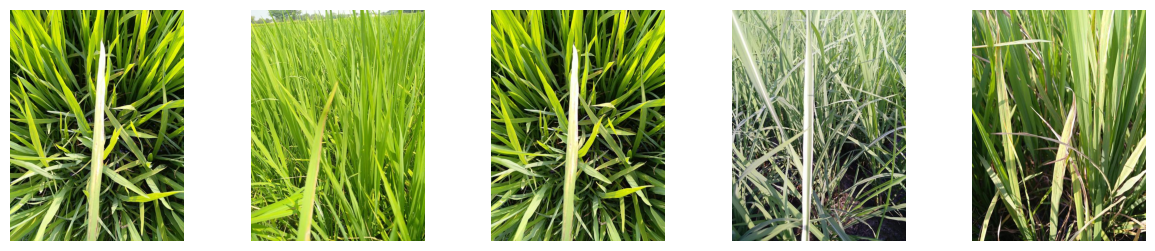

In [ ]:
def visualize_images(path, num_images=5):
    images = random.sample(os.listdir(path), num_images)
    plt.figure(figsize=(15,3))

    for i, img_name in enumerate(images):
        img = plt.imread(os.path.join(path, img_name))
        plt.subplot(1, num_images, i+1)
        plt.imshow(img)
        plt.axis('off')

    plt.show()

visualize_images("/content/drive/MyDrive/datasets/paddy-disease-classification/train_images/bacterial_leaf_blight")

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.map(lambda x, y: (x, tf.one_hot(y, depth=len(class_names))))
val_ds = val_ds.map(lambda x, y: (x, tf.one_hot(y, depth=len(class_names))))
test_ds = test_ds.map(lambda x: preprocess_input(x)).prefetch(AUTOTUNE)

In [ ]:
base = EfficientNetB4(weights='imagenet', include_top=False, input_shape=(224,224,3))
base.trainable = False

model = Sequential([
    base,
    GlobalAveragePooling2D(),
    BatchNormalization(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(len(class_names), activation='softmax')
])

model.summary()

71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb4 (Functional)     │ (None, 7, 7, 1792)     │    17,673,823 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1792)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1792)           │         7,168 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       459,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,142,569 (69.21 MB)

 Trainable params: 465,162 (1.77 MB)

 Non-trainable params: 17,677,407 (67.43 MB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

In [ ]:
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)]
)

Epoch 1/10
261/261 ━━━━━━━━━━━━━━━━━━━━ 1688s 6s/step - accuracy: 0.5213 - loss: 1.9159 - val_accuracy: 0.7554 - val_loss: 1.2963
Epoch 2/10
261/261 ━━━━━━━━━━━━━━━━━━━━ 56s 216ms/step - accuracy: 0.6772 - loss: 1.3419 - val_accuracy: 0.8203 - val_loss: 1.0090
Epoch 3/10
261/261 ━━━━━━━━━━━━━━━━━━━━ 81s 212ms/step - accuracy: 0.7433 - loss: 1.1614 - val_accuracy: 0.8544 - val_loss: 0.9337
Epoch 4/10
261/261 ━━━━━━━━━━━━━━━━━━━━ 56s 213ms/step - accuracy: 0.7833 - loss: 1.0755 - val_accuracy: 0.8611 - val_loss: 0.9046
Epoch 5/10
261/261 ━━━━━━━━━━━━━━━━━━━━ 57s 216ms/step - accuracy: 0.8036 - loss: 1.0243 - val_accuracy: 0.8890 - val_loss: 0.8602
Epoch 6/10
261/261 ━━━━━━━━━━━━━━━━━━━━ 81s 211ms/step - accuracy: 0.8228 - loss: 0.9899 - val_accuracy: 0.9000 - val_loss: 0.8481
Epoch 7/10
261/261 ━━━━━━━━━━━━━━━━━━━━ 55s 211ms/step - accuracy: 0.8403 - loss: 0.9588 - val_accuracy: 0.9005 - val_loss: 0.8259
Epoch 8/10
261/261 ━━━━━━━━━━━━━━━━━━━━ 55s 210ms/step - accuracy: 0.8481 - loss: 0.

In [23]:
# Unfreeze base model and freeze initial layers
base.trainable = True

for layer in base.layers[:300]:
    layer.trainable = False

# Freeze BatchNorm layers (critical for stable fine-tuning)
for layer in base.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

# Compile (use CategoricalCrossentropy since labels are one-hot)
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=['accuracy']
)

# Callbacks
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

# Train
history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/10
261/261 ━━━━━━━━━━━━━━━━━━━━ 178s 429ms/step - accuracy: 0.8949 - loss: 0.3862 - val_accuracy: 0.9226 - val_loss: 0.2785 - learning_rate: 1.0000e-05
Epoch 2/10
261/261 ━━━━━━━━━━━━━━━━━━━━ 61s 234ms/step - accuracy: 0.9163 - loss: 0.2934 - val_accuracy: 0.9298 - val_loss: 0.2415 - learning_rate: 1.0000e-05
Epoch 3/10
261/261 ━━━━━━━━━━━━━━━━━━━━ 70s 269ms/step - accuracy: 0.9301 - loss: 0.2459 - val_accuracy: 0.9342 - val_loss: 0.2204 - learning_rate: 1.0000e-05
Epoch 4/10
261/261 ━━━━━━━━━━━━━━━━━━━━ 60s 230ms/step - accuracy: 0.9422 - loss: 0.2198 - val_accuracy: 0.9375 - val_loss: 0.2110 - learning_rate: 1.0000e-05
Epoch 5/10
261/261 ━━━━━━━━━━━━━━━━━━━━ 82s 230ms/step - accuracy: 0.9449 - loss: 0.1949 - val_accuracy: 0.9404 - val_loss: 0.2014 - learning_rate: 1.0000e-05
Epoch 6/10
261/261 ━━━━━━━━━━━━━━━━━━━━ 69s 266ms/step - accuracy: 0.9563 - loss: 0.1724 - val_accuracy: 0.9423 - val_loss: 0.1901 - learning_rate: 1.0000e-05
Epoch 7/10
261/261 ━━━━━━━━━━━━━━━━━━━━ 60s 2

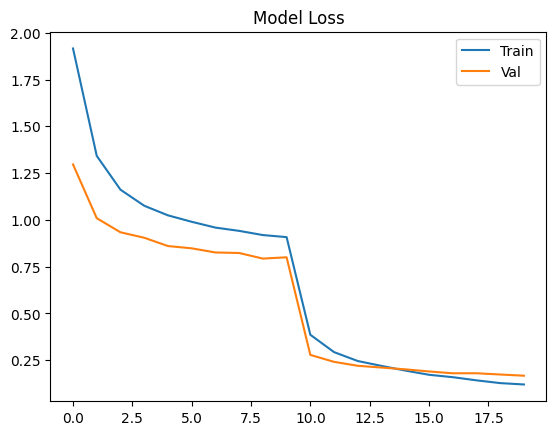

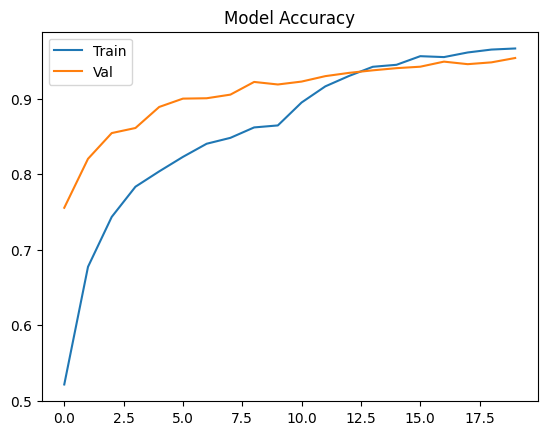

In [24]:
history = {}
for key in history1.history:
    history[key] = history1.history[key] + history2.history[key]

# Loss
plt.plot(history['loss'])
plt.plot(history['val_loss'])
plt.title('Model Loss')
plt.legend(['Train','Val'])
plt.show()

# Accuracy
plt.plot(history['accuracy'])
plt.plot(history['val_accuracy'])
plt.title('Model Accuracy')
plt.legend(['Train','Val'])
plt.show()

In [26]:
loss, acc = model.evaluate(val_ds)

print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {acc * 100:.2f}%")

66/66 ━━━━━━━━━━━━━━━━━━━━ 11s 171ms/step - accuracy: 0.9539 - loss: 0.1674
Validation Loss: 0.1674
Validation Accuracy: 95.39%


In [31]:
test_dir = "/content/drive/MyDrive/datasets/paddy-disease-classification/test_images"

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels=None,
    image_size=(224, 224),  # keep same as training
    batch_size=32,
    shuffle=False
)

# Get file names in correct order
file_names = sorted([
    f for f in os.listdir(test_dir)
    if f.lower().endswith(('.png', '.jpg', '.jpeg'))
])

# Predict
predictions = model.predict(test_ds)
pred_labels = [class_names[np.argmax(p)] for p in predictions]

# Safety check (avoid mismatch error)
assert len(file_names) == len(pred_labels), "Mismatch between files and predictions"

# Create submission
submission = pd.DataFrame({
    "image_id": file_names,
    "label": pred_labels
})

submission.to_csv("submission.csv", index=False)
submission.head()

Found 3510 files.
110/110 ━━━━━━━━━━━━━━━━━━━━ 48s 438ms/step


,image_id,label
0,200001.jpg,hispa
1,200002.jpg,normal
2,200003.jpg,downy_mildew
3,200004.jpg,blast
4,200005.jpg,blast


In [32]:
def predict_single_image(img_path):
    img = tf.keras.utils.load_img(img_path, target_size=(224,224))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = preprocess_input(img_array)
    img_array = tf.expand_dims(img_array, 0)

    pred = model.predict(img_array)
    idx = np.argmax(pred[0])
    conf = pred[0][idx]*100

    plt.imshow(img)
    plt.title(f"{class_names[idx]} ({conf:.2f}%)")
    plt.axis('off')
    plt.show()

    return class_names[idx], conf

In [33]:
def show_prediction_output(predicted_class, confidence):
    recommendations = {
        "blast": "Apply tricyclazole fungicide. Avoid excess nitrogen.",
        "brown_spot": "Use balanced fertilizers and improve drainage.",
        "hispa": "Apply chlorpyrifos or neem-based insecticide.",
        "dead_heart": "Apply stem borer control measures.",
        "tungro": "Control leafhoppers and remove infected plants.",
        "bacterial_leaf_blight": "Use resistant varieties and copper sprays.",
        "bacterial_leaf_streak": "Avoid overhead irrigation.",
        "bacterial_panicle_blight": "Ensure field sanitation.",
        "downy_mildew": "Apply systemic fungicides.",
        "normal": "Healthy crop. No action required."
    }

    print("------ SMARTCROP DISEASE DETECTION ------")
    print(f"Detected Disease : {predicted_class.replace('_',' ').title()}")
    print(f"Confidence Score : {confidence:.2f}%")
    print(f"Suggested Action : {recommendations[predicted_class]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step


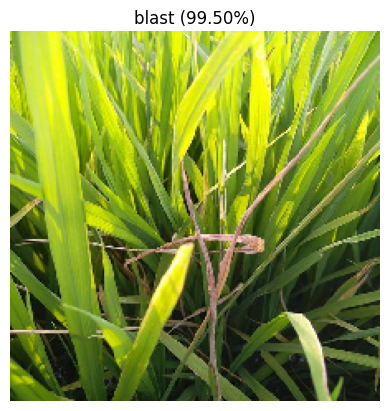

------ SMARTCROP DISEASE DETECTION ------
Detected Disease : Blast
Confidence Score : 99.50%
Suggested Action : Apply tricyclazole fungicide. Avoid excess nitrogen.


In [34]:
img_path = "/content/drive/MyDrive/datasets/paddy-disease-classification/test_images/203015.jpg"

pred_class, conf = predict_single_image(img_path)
show_prediction_output(pred_class, conf)